# Eviction Latency Analysis

This notebook analyzes the eviction latency distribution from model vs normal cache runs.

In [116]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

plt.style.use("seaborn-v0_8-paper")
sns.set_palette("pastel")
plt.rcParams["figure.figsize"] = (10, 10)
plt.rcParams["font.family"] = "Courier New"
plt.rcParams["font.size"] = 30
plt.rcParams["axes.labelsize"] = 30
plt.rcParams["axes.titlesize"] = 30
plt.rcParams["xtick.labelsize"] = 30
plt.rcParams["ytick.labelsize"] = 30
plt.rcParams["legend.fontsize"] = 20
plt.rcParams["figure.dpi"] = 300

## 1. Load Data

In [117]:
def extract_eviction_latencies(log_file: Path, max_samples: int = 10000) -> list:
    """
    Extract eviction latency values (in nanoseconds) from log file.
    Returns the first max_samples latencies found.
    """
    pattern = re.compile(r'eviction took (\d+) ns')
    latencies = []
    
    with open(log_file, 'r') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                latencies.append(int(match.group(1)))
                if len(latencies) >= max_samples:
                    break
    
    return latencies

In [118]:
model_log = Path('../data/perfdata/logoutputmodel.log')
normal_log = Path('../data/perfdata/logoutputnormal.log')

model_latencies = extract_eviction_latencies(model_log, max_samples=10000)
normal_latencies = extract_eviction_latencies(normal_log, max_samples=10000)

print(f"Model latencies: {len(model_latencies)} samples")
print(f"Normal latencies: {len(normal_latencies)} samples")

model_latencies_us = np.array(model_latencies) / 1000
normal_latencies_us = np.array(normal_latencies) / 1000

print(f"\nModel latency (us): mean={model_latencies_us.mean():.2f}, median={np.median(model_latencies_us):.2f}")
print(f"Normal latency (us): mean={normal_latencies_us.mean():.2f}, median={np.median(normal_latencies_us):.2f}")

Model latencies: 10000 samples
Normal latencies: 10000 samples

Model latency (us): mean=30.06, median=25.34
Normal latency (us): mean=26.61, median=22.17


## 2. Histogram

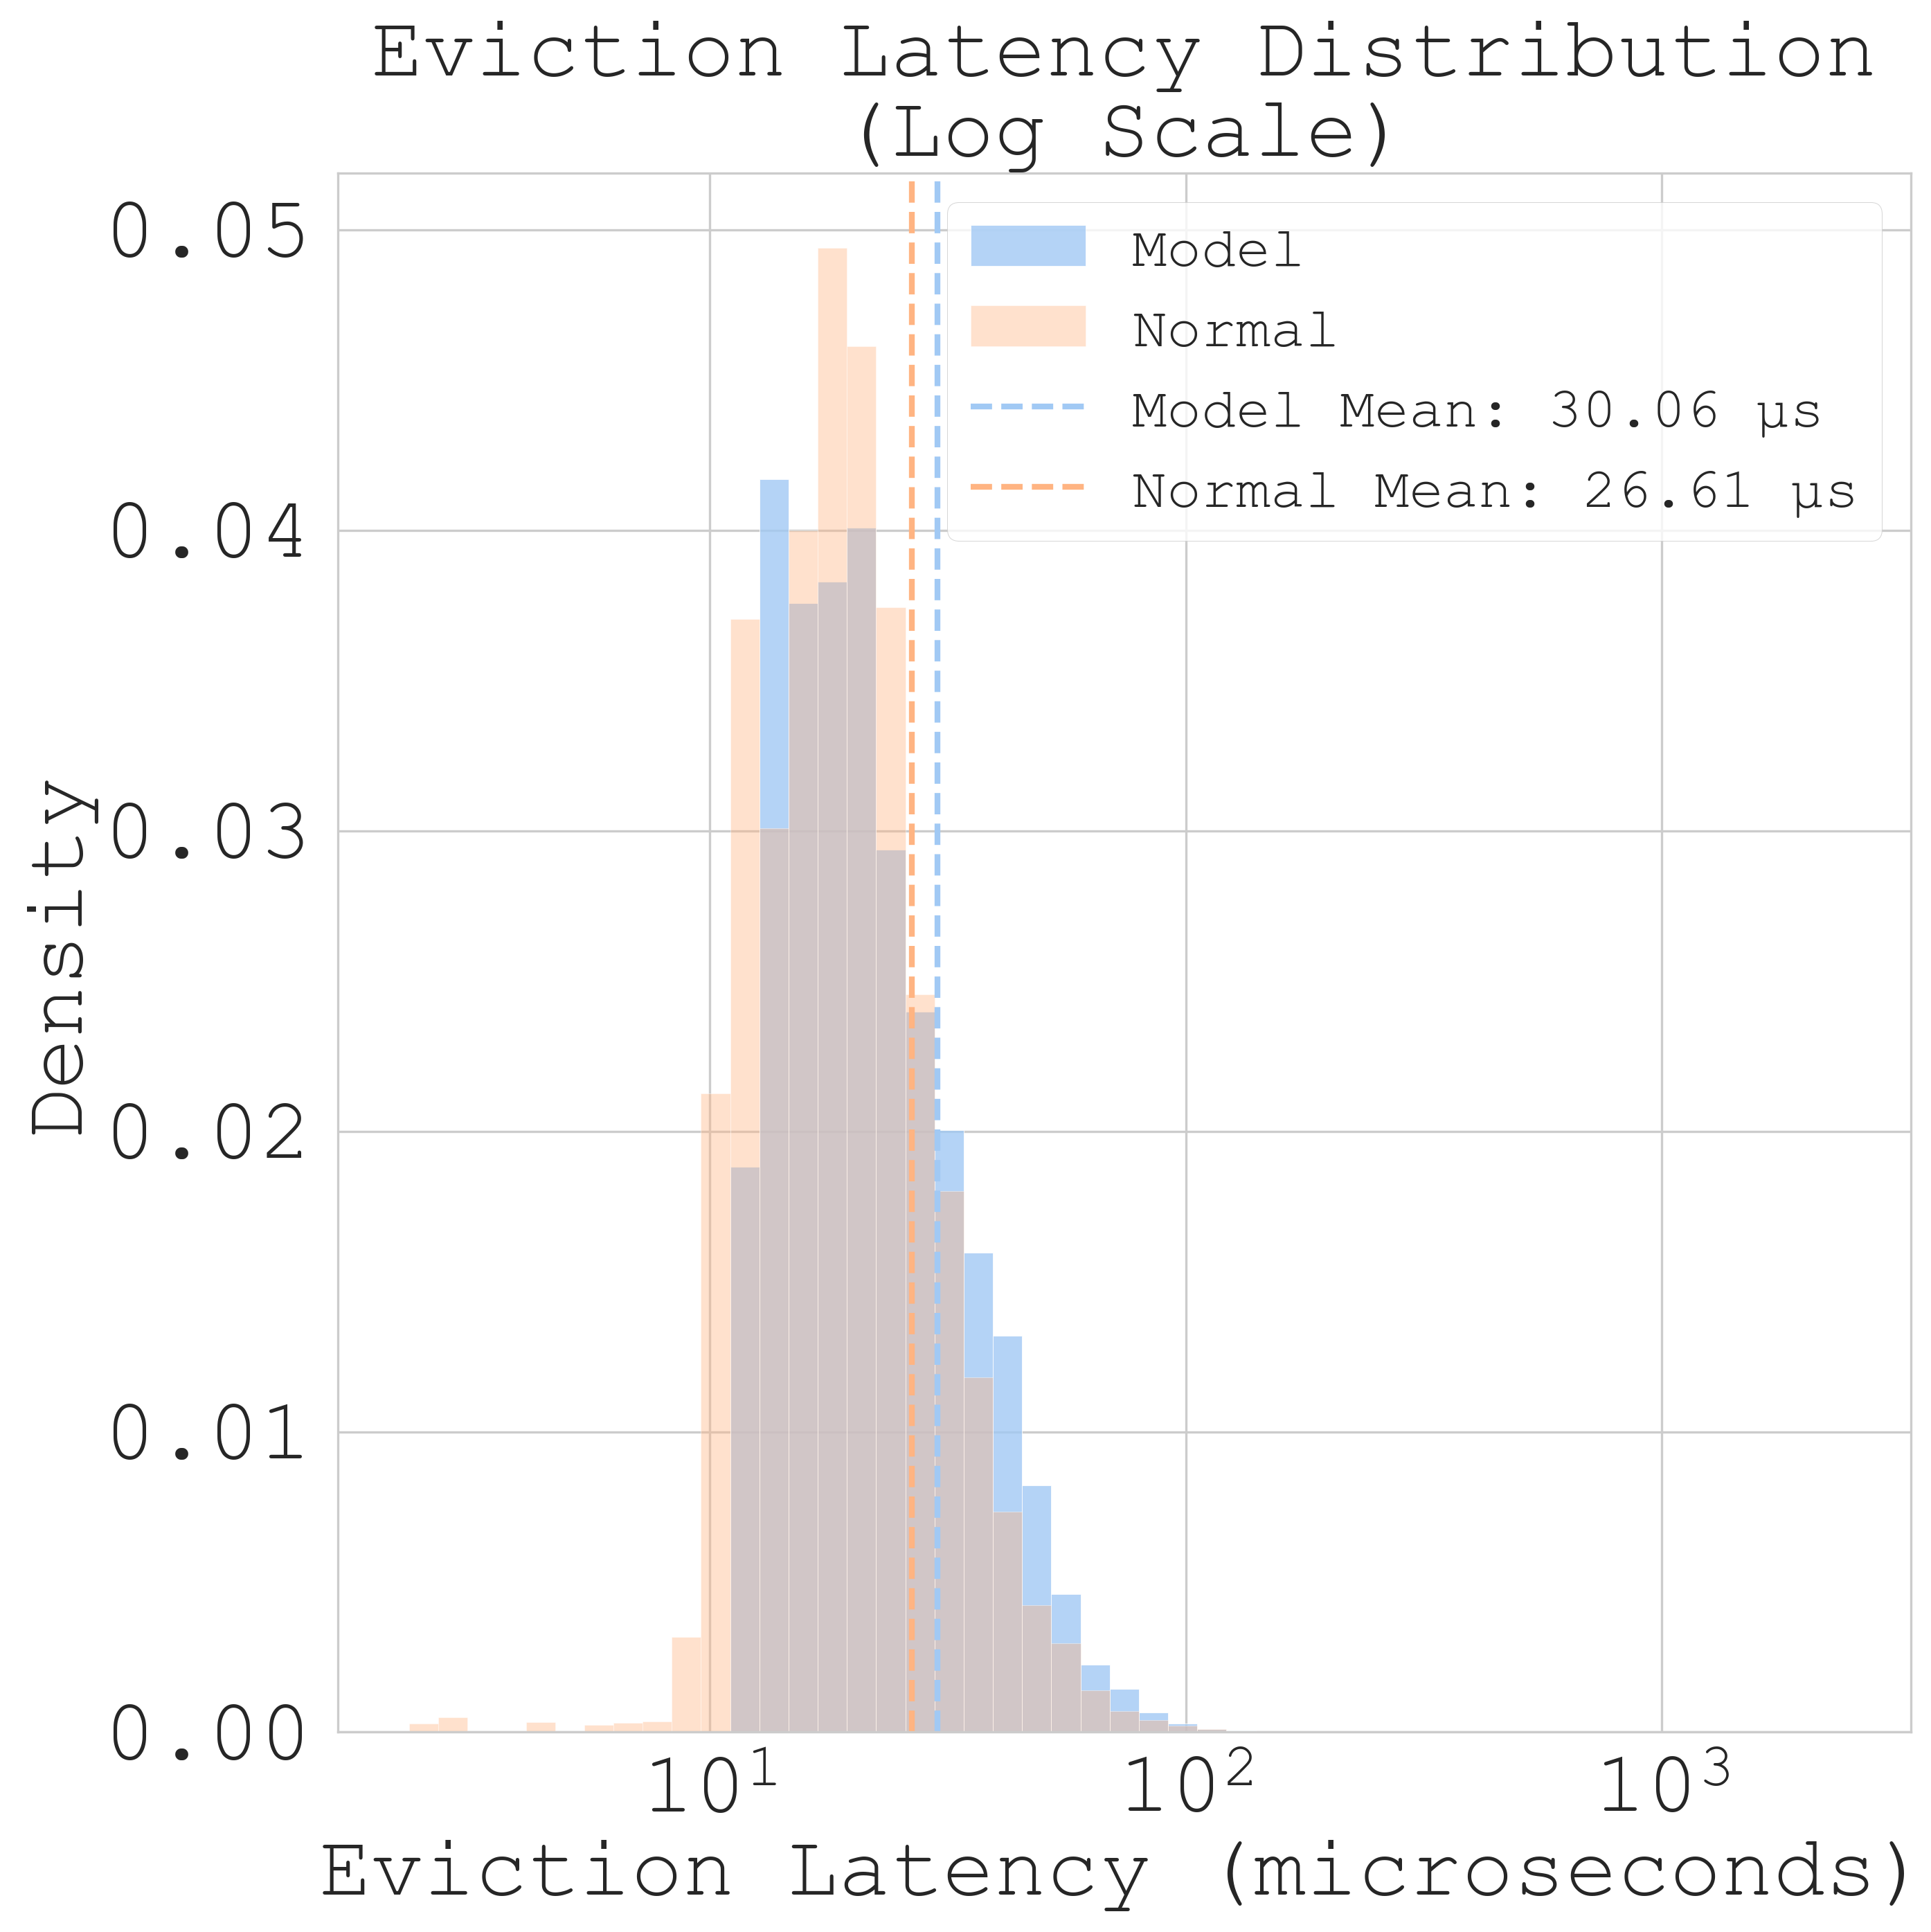

In [124]:
fig, ax = plt.subplots(figsize=(10, 10))

bins = np.logspace(np.log10(min(normal_latencies_us.min(), model_latencies_us.min())),
                   np.log10(max(normal_latencies_us.max(), model_latencies_us.max())),
                   50)

ax.hist(model_latencies_us, bins=bins, alpha=0.8, label="Model", density=True)
ax.hist(normal_latencies_us, bins=bins, alpha=0.4, label='Normal', density=True)

# Add vertical lines for means
model_mean = model_latencies_us.mean()
normal_mean = normal_latencies_us.mean()
ax.axvline(model_mean, color='C0', linestyle='--', linewidth=2, label=f'Model Mean: {model_mean:.2f} μs')
ax.axvline(normal_mean, color='C1', linestyle='--', linewidth=2, label=f'Normal Mean: {normal_mean:.2f} μs')

ax.set_xlabel('Eviction Latency (microseconds)')
ax.set_ylabel('Density')
ax.set_title('Eviction Latency Distribution\n(Log Scale)')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Cumulative Distribution Function (CDF)

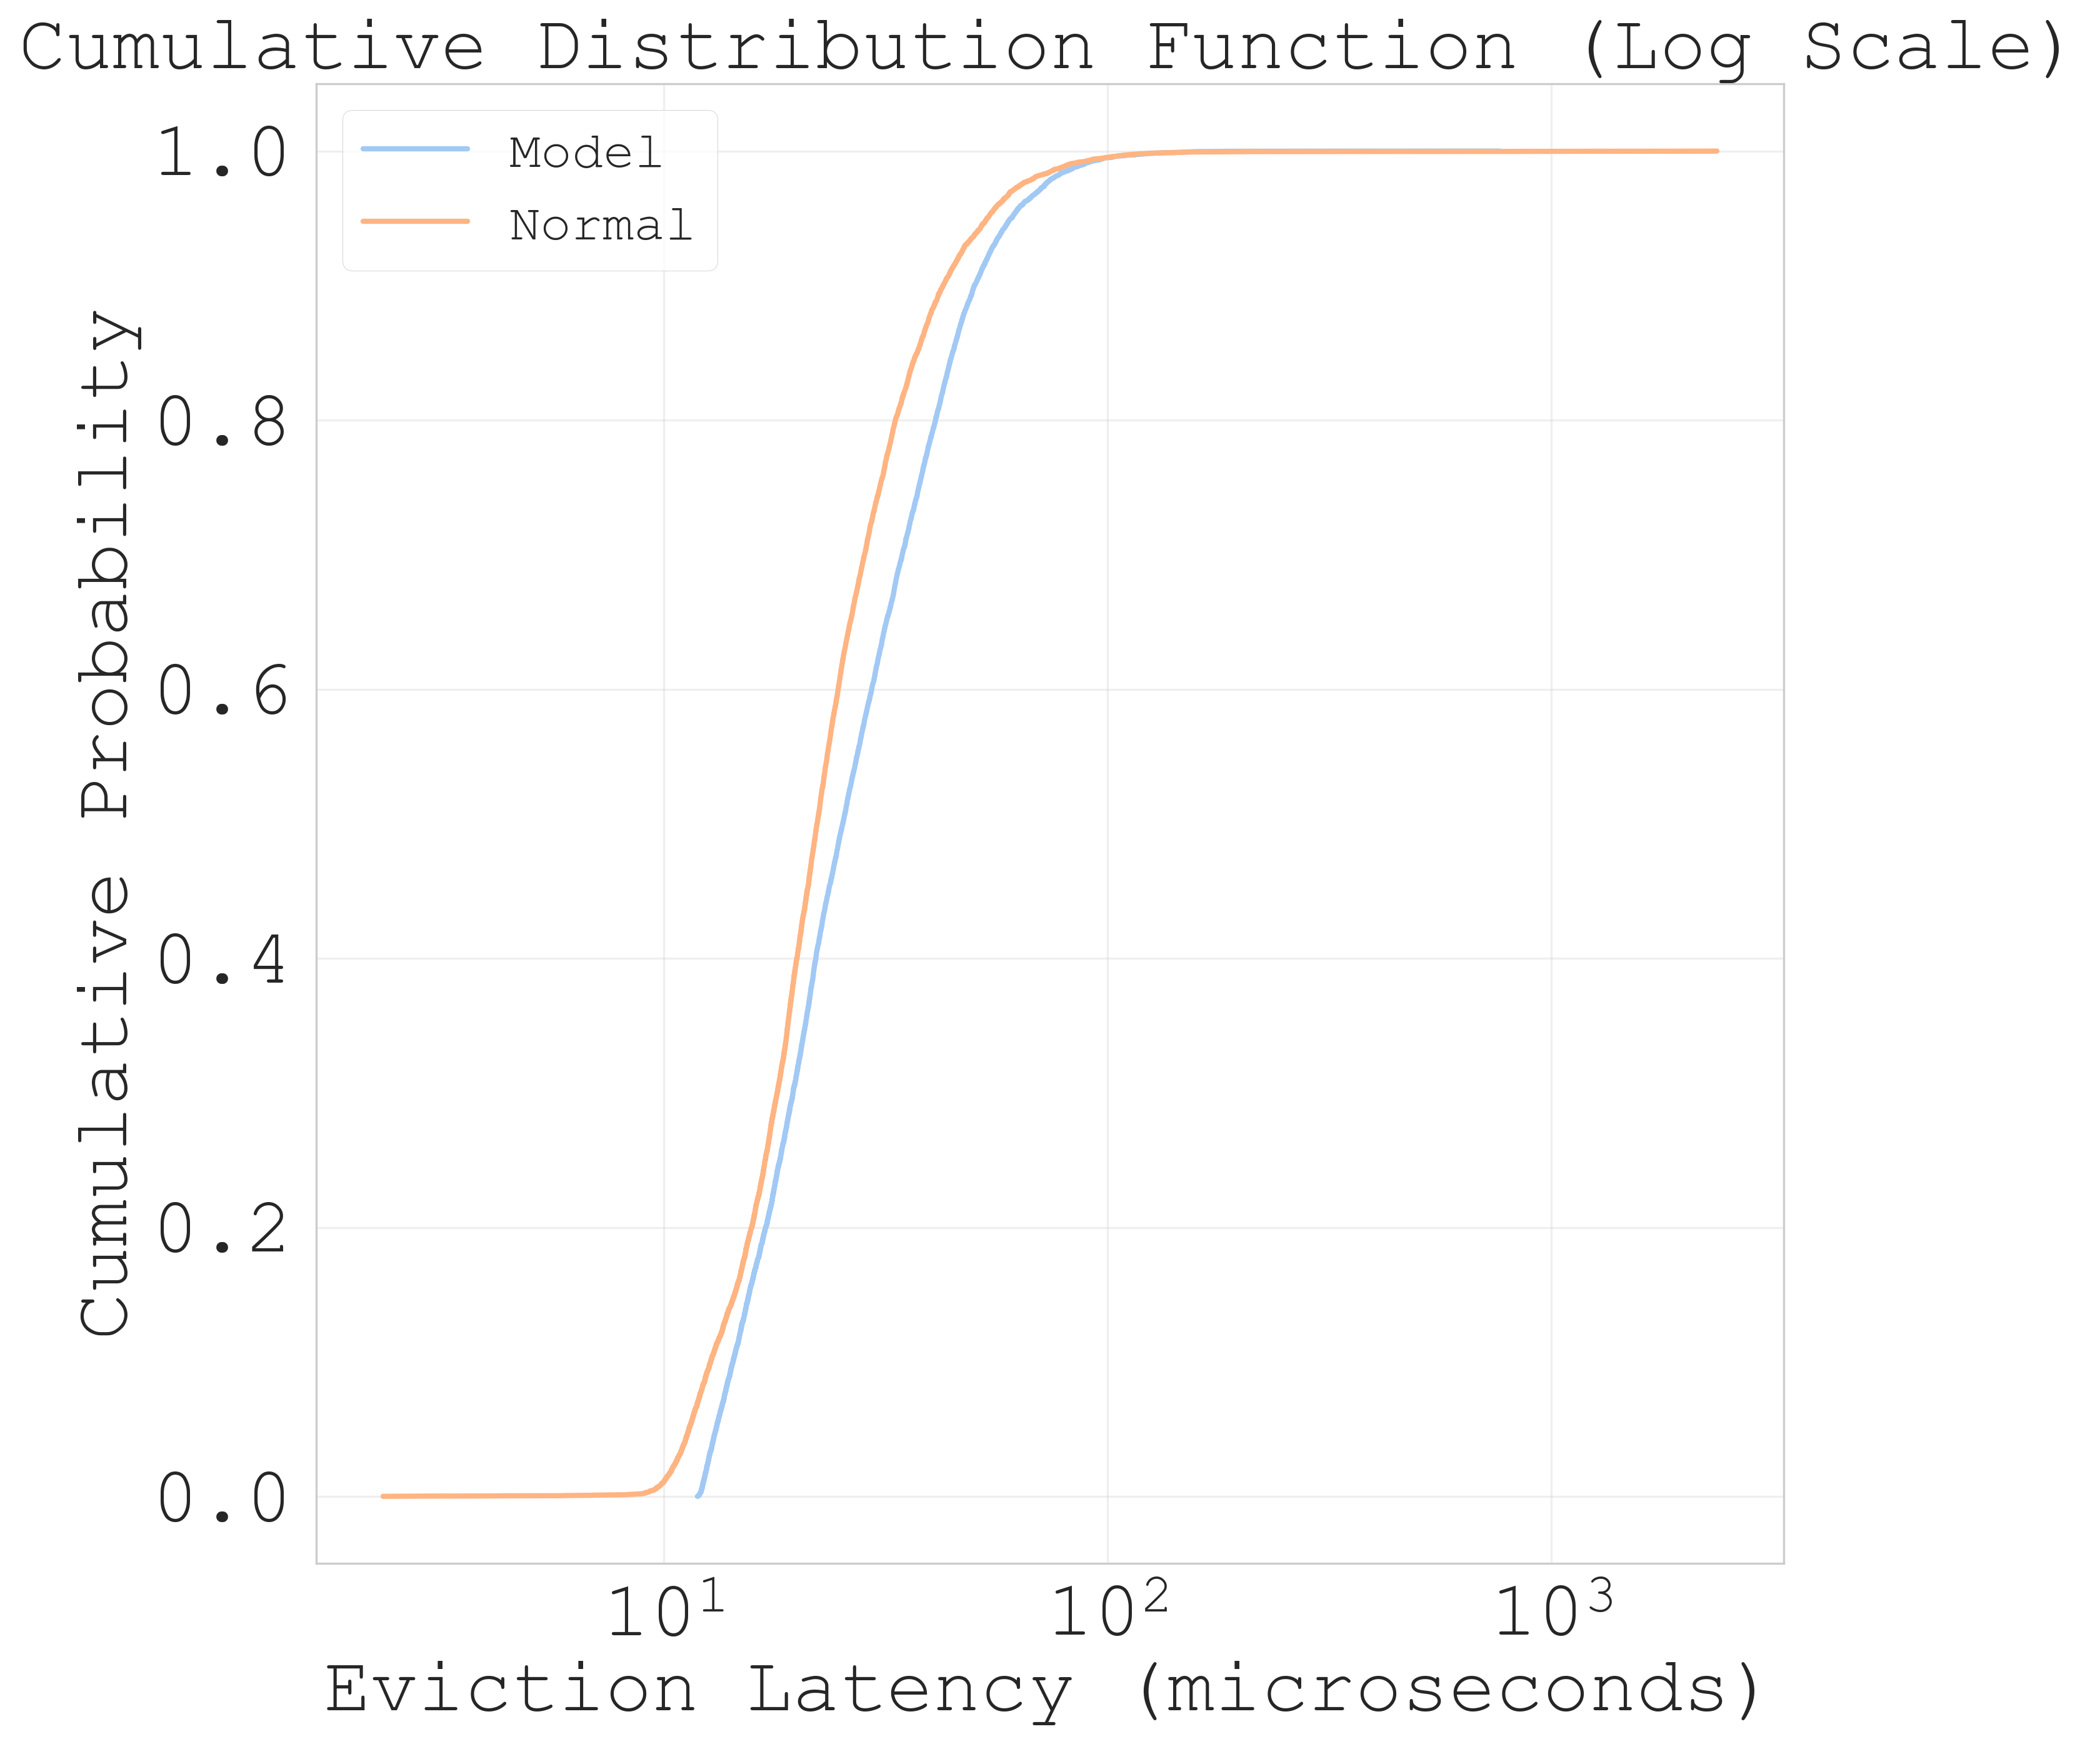

In [120]:
fig, ax = plt.subplots(figsize=(10, 10))

normal_sorted = np.sort(normal_latencies_us)
model_sorted = np.sort(model_latencies_us)

normal_cdf = np.arange(1, len(normal_sorted) + 1) / len(normal_sorted)
model_cdf = np.arange(1, len(model_sorted) + 1) / len(model_sorted)

ax.plot(model_sorted, model_cdf, label="Model", linewidth=2)
ax.plot(normal_sorted, normal_cdf, label='Normal', linewidth=2)

ax.set_xlabel('Eviction Latency (microseconds)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('Cumulative Distribution Function (Log Scale)')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Box Plot

/var/folders/r8/yrxkgs1j3075p5j9jk04pk7w0000gn/T/ipykernel_94587/2809967504.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


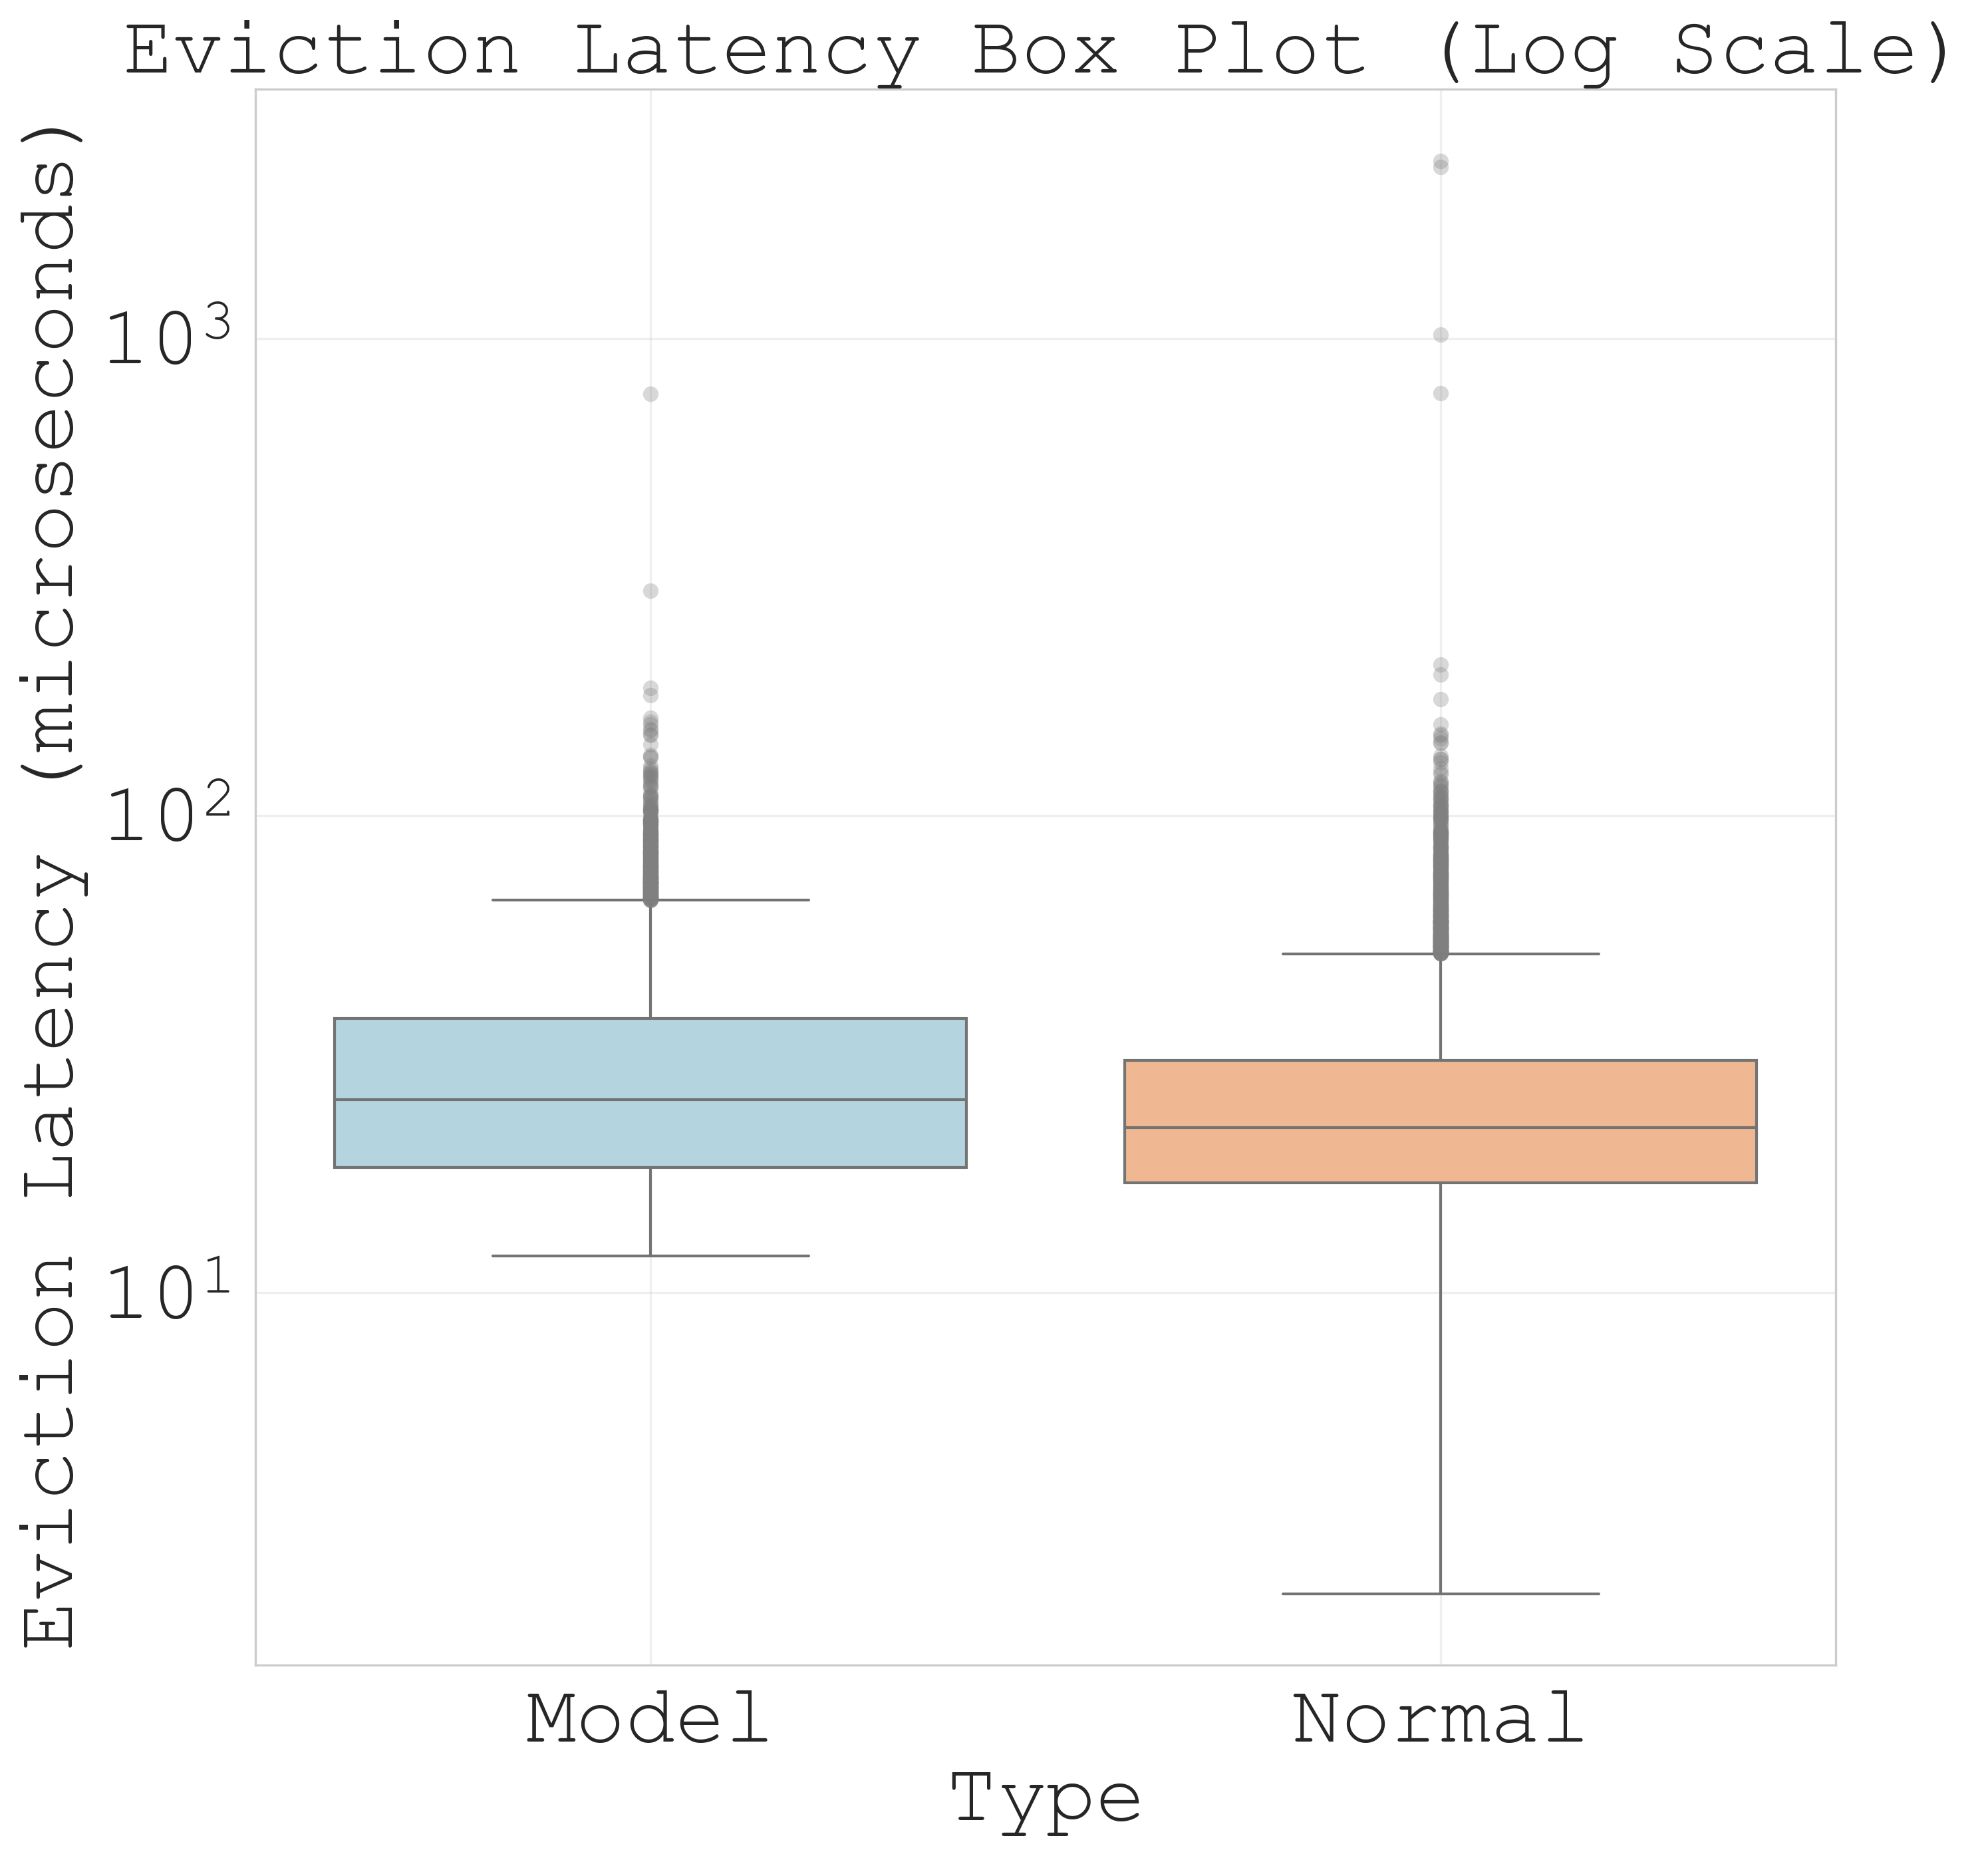

In [121]:
df = pd.DataFrame({
    'Latency (us)': np.concatenate([model_latencies_us, normal_latencies_us]),
    'Type': ['Model']*len(model_latencies_us) + ['Normal']*len(normal_latencies_us)
})

fig, ax = plt.subplots(figsize=(10, 10))
outlierstyle = {
    'markerfacecolor': 'grey',
    'markeredgewidth': 0,
    'alpha': 0.3
}
sns.boxplot(
    data=df, x="Type", y="Latency (us)", palette=["lightblue", "#ffb482"], ax=ax, flierprops=outlierstyle
)

ax.set_ylabel('Eviction Latency (microseconds)')
ax.set_title('Eviction Latency Box Plot (Log Scale)')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Statistical Test

In [122]:
t_stat, p_value = stats.ttest_ind(model_latencies_us, normal_latencies_us)

print("Independent t-test results:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.100f}")
print()

print()
print("Summary statistics:")
print(f"Model:  mean={model_latencies_us.mean():.2f} us, std={model_latencies_us.std():.2f} us")
print(f"Normal: mean={normal_latencies_us.mean():.2f} us, std={normal_latencies_us.std():.2f} us")
print(f"Difference: {model_latencies_us.mean() - normal_latencies_us.mean():.2f} us ({((model_latencies_us.mean() / normal_latencies_us.mean() - 1) * 100):.2f}%)")

Independent t-test results:
t-statistic: 8.2219
p-value: 0.0000000000000002124820085377110337916621741994414818481863718247285022222570205485681071877479553223


Summary statistics:
Model:  mean=30.06 us, std=18.18 us
Normal: mean=26.61 us, std=37.76 us
Difference: 3.45 us (12.95%)


## 7. Power Analysis

In [123]:
from statsmodels.stats.power import TTestPower

mean_diff = model_latencies_us.mean() - normal_latencies_us.mean()
pooled_std = np.sqrt((model_latencies_us.std()**2 + normal_latencies_us.std()**2) / 2)
cohens_d = mean_diff / pooled_std

print("Power Analysis Results:")
print(f"Cohen's d (effect size): {cohens_d:.4f}")
print()

power_analysis = TTestPower()

achieved_power = power_analysis.power(
    effect_size=cohens_d,
    nobs=len(model_latencies_us),
    alpha=0.05,
    alternative='two-sided'
)

print(f"Achieved statistical power: {achieved_power:.4f} ({achieved_power*100:.2f}%)")

Power Analysis Results:
Cohen's d (effect size): 0.1163

Achieved statistical power: 1.0000 (100.00%)
